In [5]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional, Annotated, Literal
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [6]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
class ChatState(BaseModel):

    messages: Annotated[list[BaseModel], add_messages]

In [8]:
def chat_node(state: ChatState):
    response = model.invoke(state.messages)

    return{
        'messages': [response]
    }

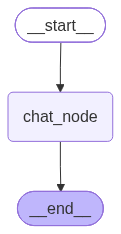

In [10]:
graph = StateGraph(ChatState)

# nodes
graph.add_node('chat_node', chat_node)

# edge
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile()

workflow